In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


V_current_level = 235.,235.,355.,290.,275.,230.,205.,185.,120.,230.,230.,215.,230.,230.,230. #Leakage current measured at this V
V_current_monitor = V_current_level #Voltage up to which the current level is monitored
VBD_expected = 265.,265.,385.,320.,307.,260.,240.,213.,150.,240.,240.,240.,240.,240.,240.
VBD_expected_sigma = 6.,6.,7.,7.,7.,8.,7.,8.,5.,5.,5.,12.,5.,5.,5.
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 50. #sensor discarded if I > I_thr [uA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [uA]
I_compliance_minimum = 0.005 # [uA] VBD calculation performed only if compliance was set above this threshold
k_thr = 20. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E6 # conversion from [A] (raw data) to [uA] (used in the final plots)
start_bd_calculation = 5 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 0.001  #low and high ranges for I@100V plot [uA]
high_iv_range = 10
low_vbd_range = 0 #low and high ranges for VBD plot [V]
high_vbd_range = 300
n_wafer = 15 #
n_row = 7 #
n_col = 8 # 
start_wafer = 1 #first wafer number in the dataset
start_row = 2 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
bcurrent = True
bvoltage = False
bcategory = False
bnoisy = False
save = False
verbose = True
write_json = False  #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2024, 6, 20, 12, 0, 0) # choose the correct date to be insterted in the json files that will be uploaded to the database. Please note each json file has a single date, so tests performed in different days should be uploaded as different json files
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

if(bcategory): 
    root.gStyle.SetPalette(3,palette) # custom palette used for Categories

if(bvoltage):
    #root.gStyle.SetPalette("Black Body") # palette for VBD
    root.gStyle.SetPalette(70) # palette for VBD

if(bcurrent or bnoisy):
    #root.gStyle.SetPalette("Black Body") # palette for I@V_current_level
    root.gStyle.SetPalette(70)
    root.TColor.InvertPalette()

invert_polarity=True

#file_qa = root.TFile.Open("/Users/icosivi/Desktop/LC2_W12.root")
file_qa = root.TFile.Open("/Users/icosivi/Desktop/pippo.root")
tree_qa = file_qa.Get("Tree")
  
counter_qa = 0
I_qa_100V = 0.
VBD_qa_u = 0.
VBD_qa_d = 0.
k_qa_u = []
k_qa_d = []
k_qa_u.append(0.)
k_qa_u.append(0.)
k_qa_d.append(0.)
k_qa_d.append(0.)

tests_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_vbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_i_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vbump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_serialn = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
#vnoisy_qa = None
hI_qa_100V = []
hV_qa = []
hbump_qa = []
hnoisy_qa = []
hcount_qa = []
min_I = []
hiMax = []

for i in range(n_wafer):
    #hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+1), "I@"+str(V_current_level[i])+"V on-wafer W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+1), r"I@V_{MaxOp} ETL site W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hV_qa.append( TH2F( "V_qa_W"+str(i+1), "VBD ETL site W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    #hV_qa.append( TH1F( "V_qa_W"+str(i+1), "VBD on-wafer W"+str(i+1), int((450-0)/10.), 0, 450 ) )
    min_I.append(1000)

    hbump_qa.append( TH2F( "bump_qa_W"+str(i+1), "Categories on-wafer W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )
    hnoisy_qa.append( TH2F( "noisy_qa_W"+str(i+1), "Bad pads on-wafer W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
good_sensors_counter_qa= 0. #Fraction of GOOD sensors
bad_sensors_counter_qa= 0. #Fraction of BAD sensors
medium_sensors_counter_qa= 0. #Fraction of MEDIUM sensors
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False

sensor = "Prototype LGAD"
sensor_geom = "16x16-T9"
vendor = "FBK"
production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "Universita e INFN Torino" # where the test was performed

if(write_json):
    json_filename="ETL_site_IV"
    
save_path = '/Users/icosivi/Desktop/plot_UFSDLF/'
wb = pd.read_excel('/Users/icosivi/Desktop/LFoundry/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')

In [ ]:
# run this block to analyze I_PAD1. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    v_serialn[event.wafer-start_wafer][event.column-start_col][event.row-start_row] = str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])
    dumb_counter+=1
    if(int(event.I_PAD1.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD1.at(event.I_PAD1.size()-1)<0 ): 
        Iback = [abs(i) for i in event.I_PAD1]
        #Iback = [float(-i) for i in event.I_PAD1]
        for idx, i in enumerate(event.I_PAD1):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.I_PAD1]
        #Iback = [i for i in event.I_PAD1]
        for idx, i in enumerate(event.I_PAD1):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD1.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD1.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        '''
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor[event.wafer-start_wafer] and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        if( I_qa_100V<0. ): 
          iv_quality=False
        '''
        
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
        
        #print(VBD_qa_u)
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          #if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
          if( i!=0 and Vbias[i-1]<(VBD_qa_u-10) and Vbias[i]>=(VBD_qa_u-10) and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer])):
            if( Vbias[i]==VBD_qa_u-10 ): 
            #if( Vbias[i]==V_current_level[event.wafer-start_wafer] ):
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((VBD_qa_u-10)-Vbias[i]) + Iback[i]
              #I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=(VBD_qa_u-10) and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      
        if( VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 and VBD_qa_d<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
          if(verbose): 
            print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column))
        
        if( iv_quality and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_u<(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           hiMax.append(float(I_qa_100V))
          else:
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and (VBD_qa_u<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) or VBD_qa_u>=(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]))) ):
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

0.08429524698753617
 
-1000000000.0
 
-1000000000.0
 
-1000000000.0
 
0.16770352976217498
 
-1000000000.0
 
0.09064882399329496
 
0.06029881123414232
 
0.058752292836181004
 
0.12413713269928411
 
-1000000000.0
 
-1000000000.0
 
-1000000000.0
 
-1000000000.0
 
-1000000000.0
 
0.16825066382372517
 
-1000000000.0
 
-1000000000.0
 
0.16760418270620236
 
-1000000000.0
 
-1000000000.0
 
0.18213466710469398
 


In [ ]:
# run this block to analyze I_PAD2. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    v_serialn[event.wafer-start_wafer][event.column-start_col][event.row-start_row] = str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])
    dumb_counter+=1
    if(int(event.I_PAD2.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD2.at(event.I_PAD2.size()-1)<0 ): 
        Iback = [float(-i) for i in event.I_PAD2]
        for idx, i in enumerate(event.I_PAD2):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [i for i in event.I_PAD2]
        for idx, i in enumerate(event.I_PAD2):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD2.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD2.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        '''
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor[event.wafer-start_wafer] and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        if( I_qa_100V<0. ): 
          iv_quality=False
        '''
          
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
        
        print(VBD_qa_u)
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
          #if( i!=0 and Vbias[i-1]<(VBD_qa_u-10) and Vbias[i]>=(VBD_qa_u-10) and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer])):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((VBD_qa_u-10)-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=(VBD_qa_u-10) and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break
        
        I_qa_100V = current_conversion_value*I_qa_100V
        print(I_qa_100V)
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      
        if( VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 and VBD_qa_d<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
          if(verbose): 
            print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column))
        
        if( iv_quality and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_u<(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           hiMax.append(float(I_qa_100V))
          else:
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and (VBD_qa_u<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) or VBD_qa_u>=(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]))) ):
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
# run this block to analyze I_PAD3. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    v_serialn[event.wafer-start_wafer][event.column-start_col][event.row-start_row] = str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])
    dumb_counter+=1
    if(int(event.I_PAD3.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD3.at(event.I_PAD3.size()-1)<0 ): 
        Iback = [float(-i) for i in event.I_PAD3]
        for idx, i in enumerate(event.I_PAD3):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [i for i in event.I_PAD3]
        for idx, i in enumerate(event.I_PAD3):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD3.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD3.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        '''
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor[event.wafer-start_wafer] and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        if( I_qa_100V<0. ): 
          iv_quality=False
        '''
          
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
        
        print(VBD_qa_u)
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
          #if( i!=0 and Vbias[i-1]<(VBD_qa_u-10) and Vbias[i]>=(VBD_qa_u-10) and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer])):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((VBD_qa_u-10)-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=(VBD_qa_u-10) and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break
        
        I_qa_100V = current_conversion_value*I_qa_100V
        print(I_qa_100V)
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      
        if( VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 and VBD_qa_d<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
          if(verbose): 
            print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column))
        
        if( iv_quality and VBD_qa_u>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_u<(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]) and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) ):
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           hiMax.append(float(I_qa_100V))
          else:
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and (VBD_qa_u<=(VBD_expected[event.wafer-start_wafer]-3*VBD_expected_sigma[event.wafer-start_wafer]) or VBD_qa_u>=(VBD_expected[event.wafer-start_wafer]+3*VBD_expected_sigma[event.wafer-start_wafer]))) ):
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
import statistics

print(statistics.mean(hiMax))
print(statistics.stdev(hiMax))

In [4]:
serial_num_counter=0

for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          #if( i==0 ):
          if( i<20 ):
             if(vcount_bump_qa[i][j][k] != 0):
               #serial_num_counter += 1
               #serial_num = str(int(serial_num_counter)).zfill(3)
               serial_num = str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Row'] == k+start_row) & (wb['Column'] == j+start_col)]['SerialNumber'].iloc[0])
               
             if(vcount_vbd_qa[i][j][k]!=0): 
               hV_qa[i].Fill( j+start_col, k+start_row, vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               #hV_qa[i].Fill( vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               
             if(vcount_i_qa[i][j][k]!=0): 
               hI_qa_100V[i].Fill( j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )
             
             #if(vnoisy_qa[i][j][k]!=0) hnoisy_qa[i]->Fill(j+2,k+2,1);
             #else hnoisy_qa[i]->Fill(j+2,k+2,0);
  
             if(vcount_bump_qa[i][j][k]<0): 
               hnoisy_qa[i].Fill(j+start_col,k+start_row,-1000)
               
               pippo = {'component': v_serialn[i][j][k],
                        'type': 'Sensor IV - ETL Site',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': 'fsiviero',
                        'version': '0.0',
                        'data':{
                         'leakage_current_uA': None,
                         'breakdown_voltage_V': None, 
                         'category': None,
                         'gain_category': None,  
                         'current': vi_raw[i][j][k],
                         'voltage': v_raw[i][j][k]
                        }
                       }
               
               tests_json.append(pippo)
          
             if( vcount_bump_qa[i][j][k] > 0 ):
               total_sensors_counter_qa+=1
               
               vendor_leakage_json = str()
               vendor_vbd_json = str()
               vendor_category_json = str()
               
               if(vcount_i_qa[i][j][k]!=0): 
                 vendor_leakage_json = float(vi_qa[i][j][k]/vcount_i_qa[i][j][k])
               else:
                 vendor_leakage_json = None
                 
               if(vcount_vbd_qa[i][j][k]!=0):
                 vendor_vbd_json = float(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
               else:
                 vendor_vbd_json = None
                 
               if( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]==1 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,1)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 good_sensors_counter_qa+=1
                 vendor_category_json = "GOOD"
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,3)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 bad_sensors_counter_qa+=1
                 vendor_category_json = "BAD"
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>1 and vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]<=2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,2)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,1)
                 medium_sensors_counter_qa+=1
                 vendor_category_json = "MEDIUM"

               if vendor_category_json is "BAD":
                 vendor_gain_category_json=None
               else:
                if vendor_vbd_json is None:
                 vendor_gain_category_json=None
                elif( vendor_vbd_json>(VBD_expected[i]-VBD_expected_sigma[i]/2.) and vendor_vbd_json<(VBD_expected[i]+VBD_expected_sigma[i]/2.) ):
                 vendor_gain_category_json='B'
                elif( vendor_vbd_json<=(VBD_expected[i]-VBD_expected_sigma[i]/2.) and vendor_vbd_json>(VBD_expected[i]-3*VBD_expected_sigma[i]) ):
                 vendor_gain_category_json='A' 
                elif( vendor_vbd_json>=(VBD_expected[i]+VBD_expected_sigma[i]/2.) and vendor_vbd_json<(VBD_expected[i]+3*VBD_expected_sigma[i]) ):
                 vendor_gain_category_json='C' 
               
               pippo = {'component': v_serialn[i][j][k],
                        'type': 'Sensor IV - ETL Site',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': 'fsiviero',
                        'version': '0.0',
                        'data':{
                         'leakage_current_uA': vendor_leakage_json,
                         'breakdown_voltage_V': vendor_vbd_json, 
                         'category': vendor_category_json,  
                         'gain_category': vendor_gain_category_json,
                         'current': vi_raw[i][j][k],
                         'voltage': v_raw[i][j][k]
                        }
                       }
               
               tests_json.append(pippo)

if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

if(verbose):
  print("Fraction of GOOD sensors (on-wafer): "+str(good_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of MEDIUM sensors (on-wafer): "+str(medium_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of BAD sensors (on-wafer): "+str(bad_sensors_counter_qa/total_sensors_counter_qa))
  print("Fraction of non-empty IVs: "+str(non_empty_counter/dumb_counter))
  print("Fraction of IVs with non-zero values: "+str(non_zero_counter/dumb_counter))

Fraction of GOOD sensors (on-wafer): 0.38095238095238093
Fraction of MEDIUM sensors (on-wafer): 0.0
Fraction of BAD sensors (on-wafer): 0.6190476190476191
Fraction of non-empty IVs: 1.0
Fraction of IVs with non-zero values: 1.0


<>:77: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:77: SyntaxWarning: "is" with a literal. Did you mean "=="?
/var/folders/qv/rs5lq5zd0kzd81_zslwl_h880000gn/T/ipykernel_50071/237094926.py:77: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if vendor_category_json is "BAD":


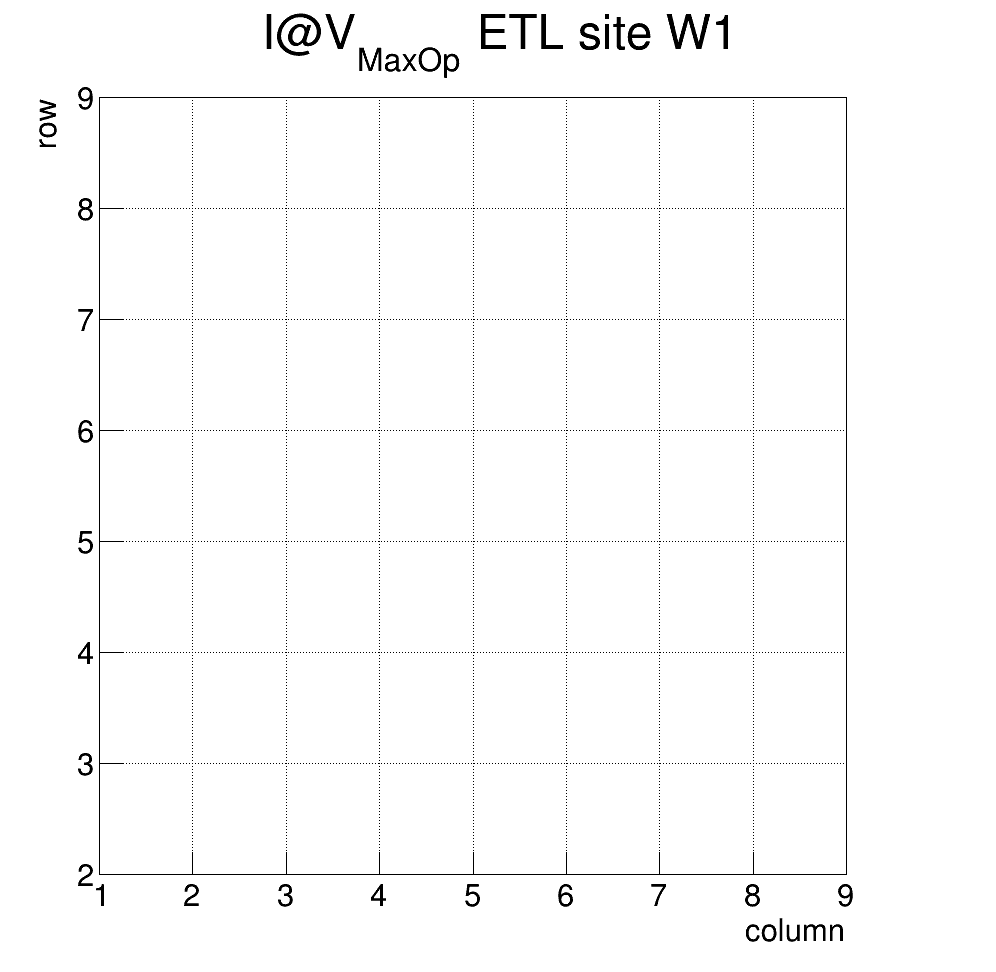

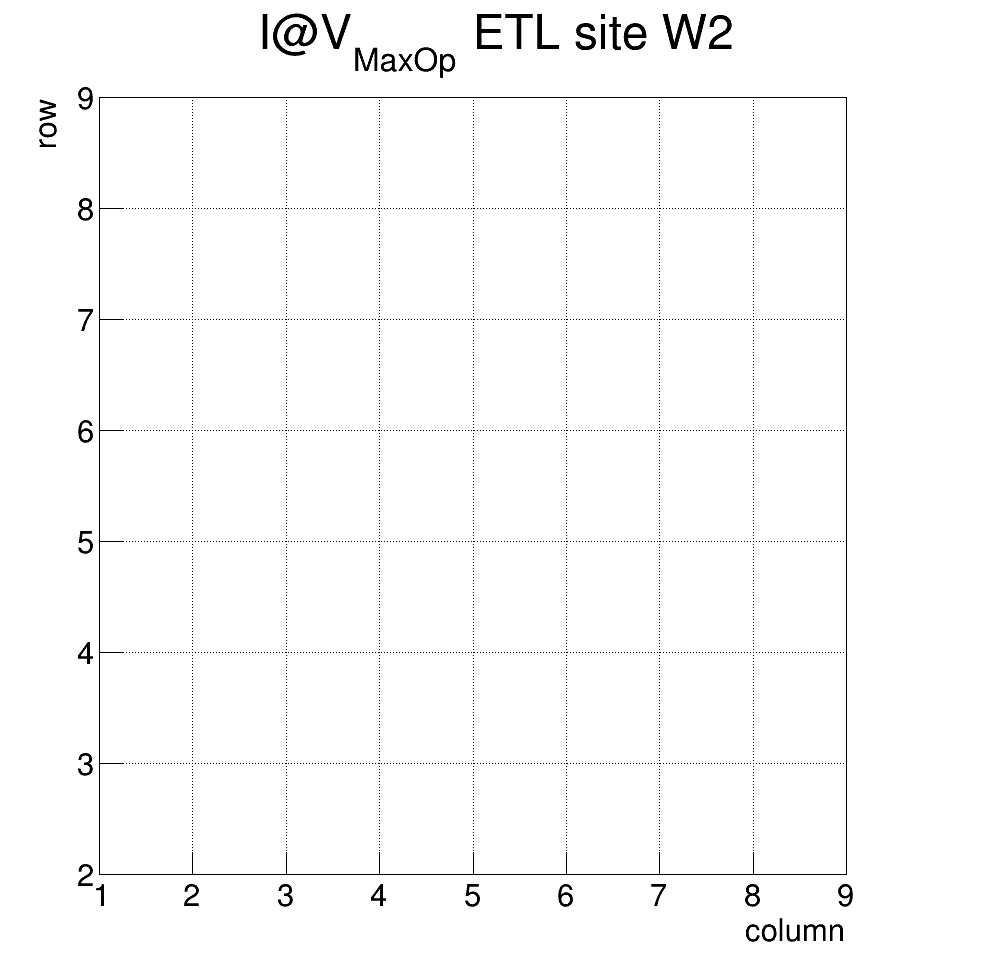

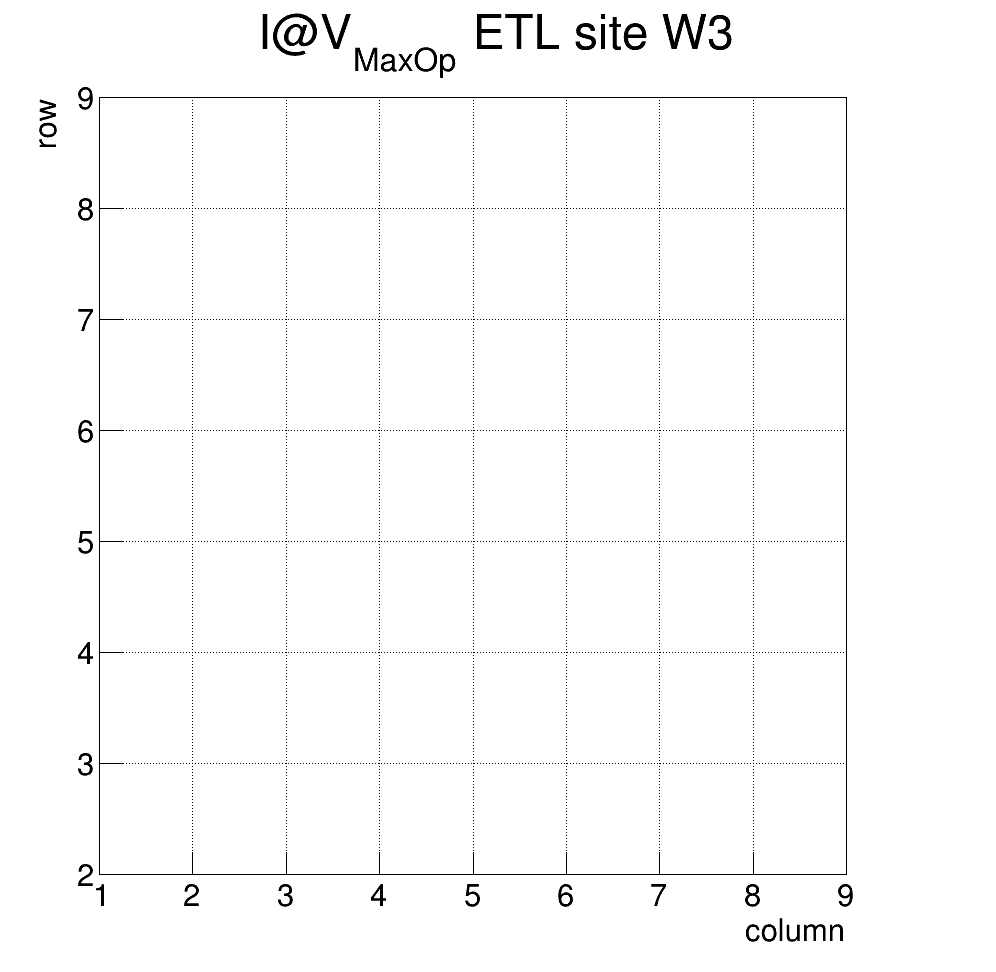

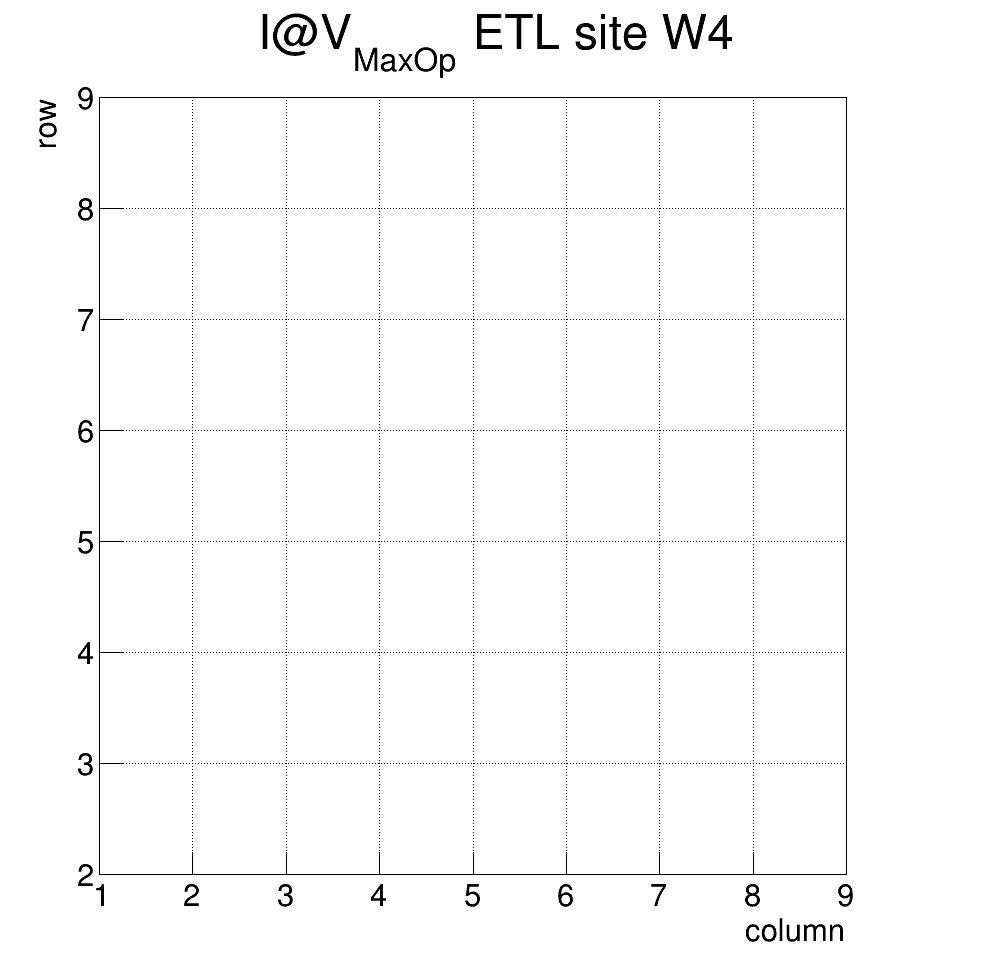

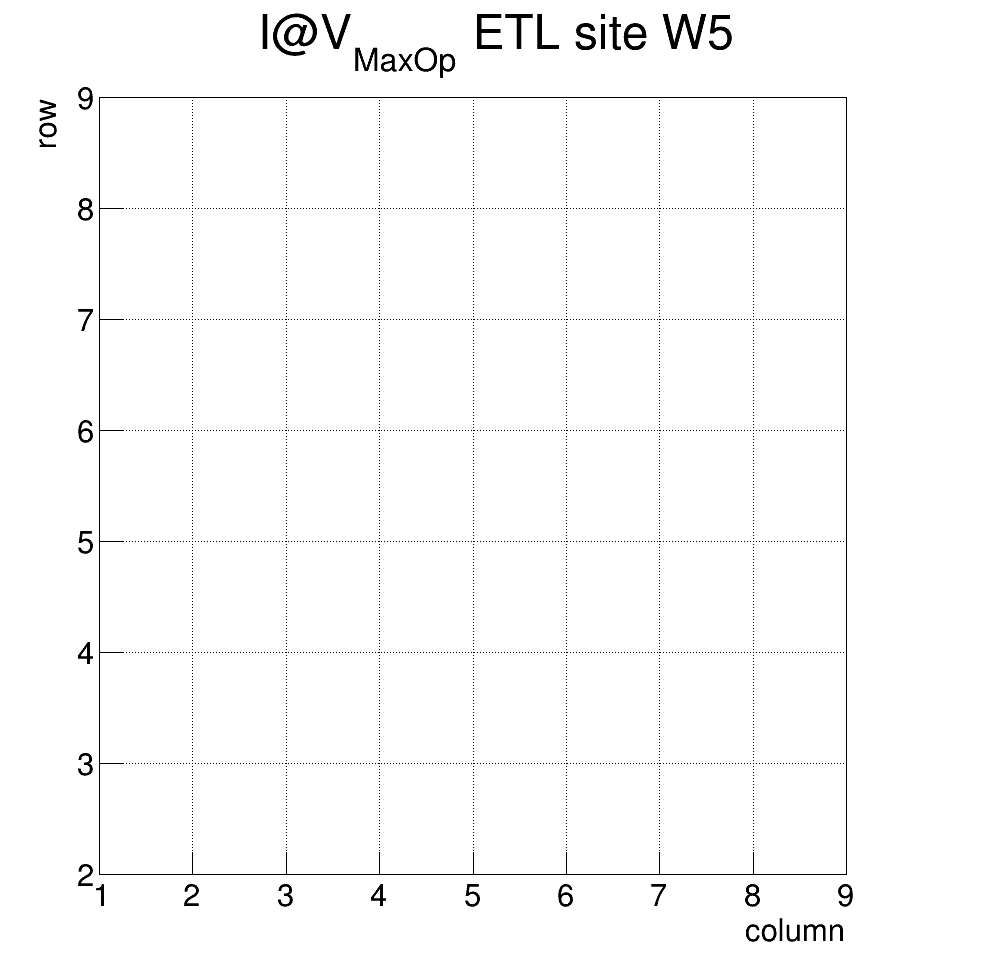

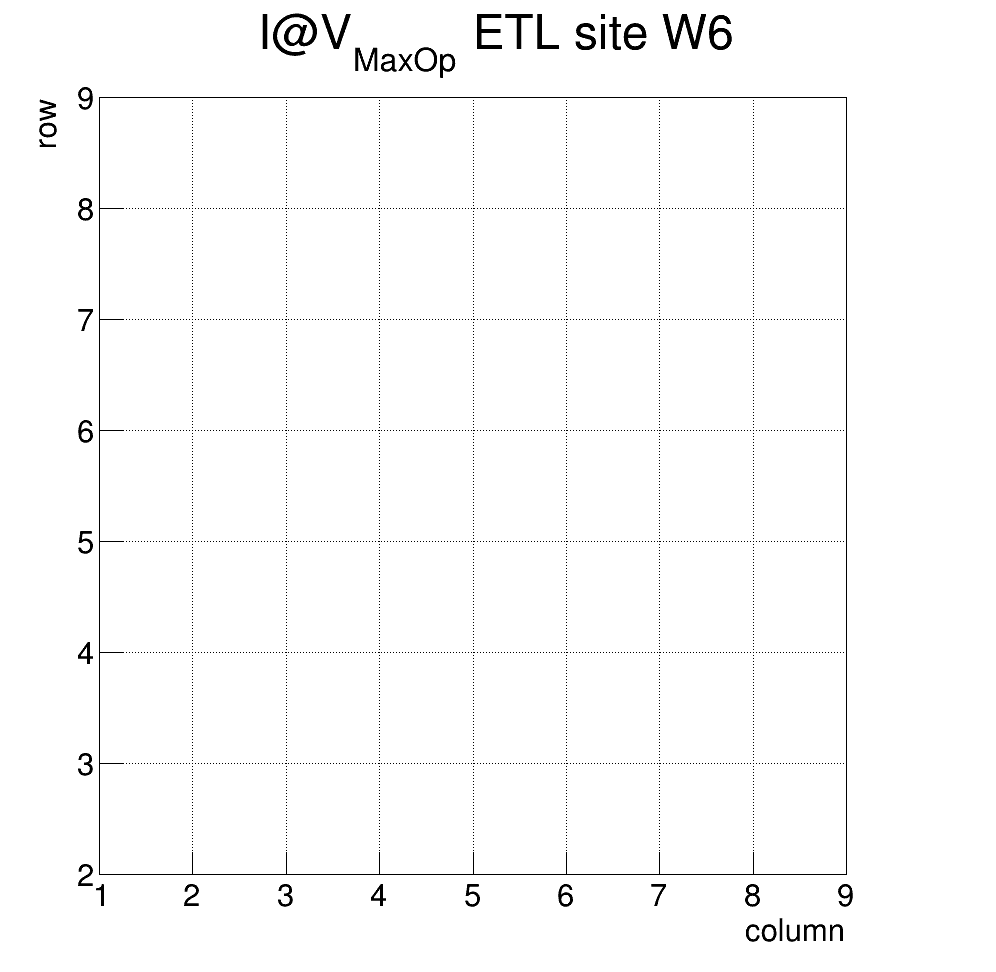

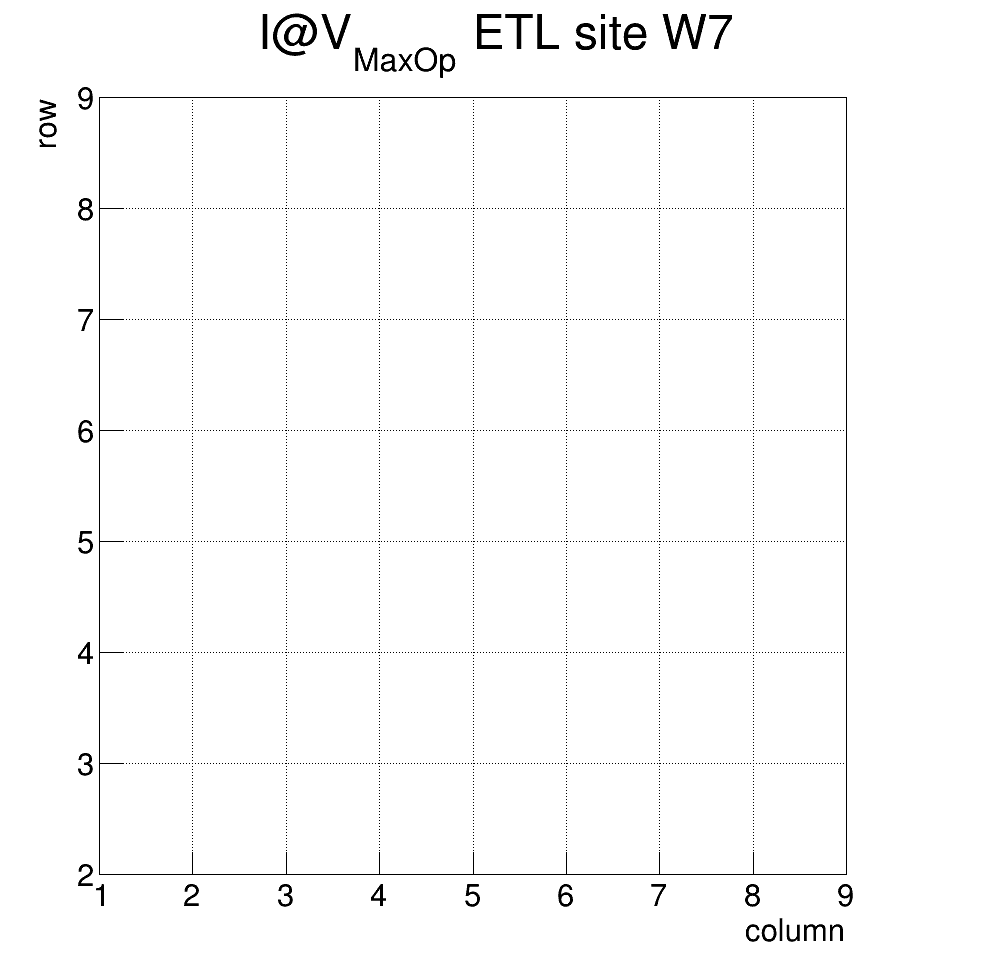

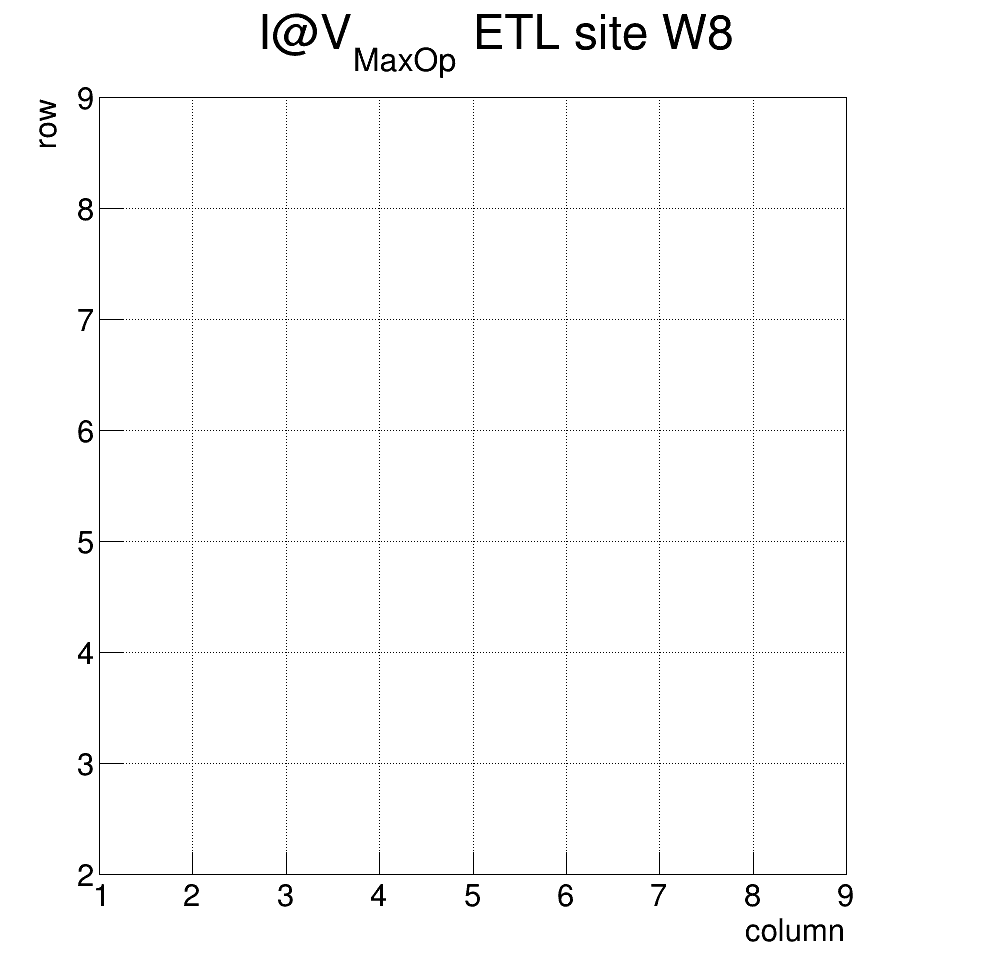

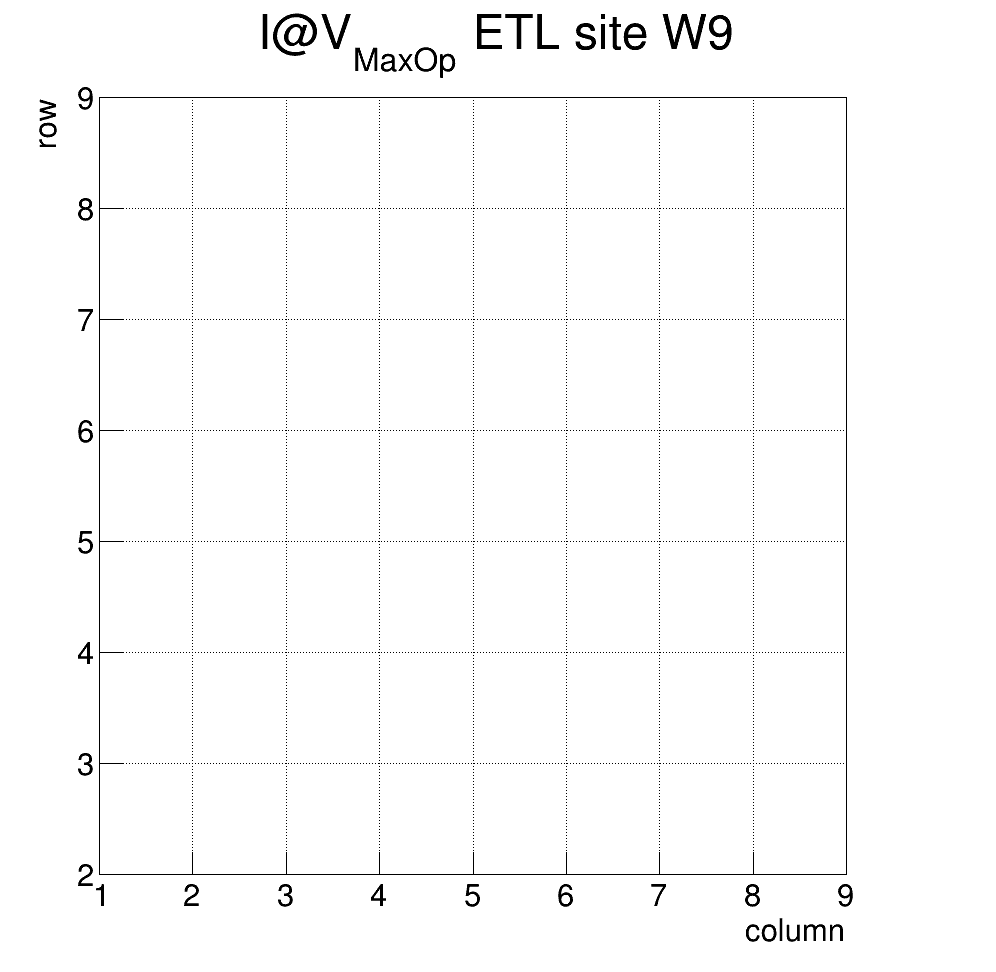

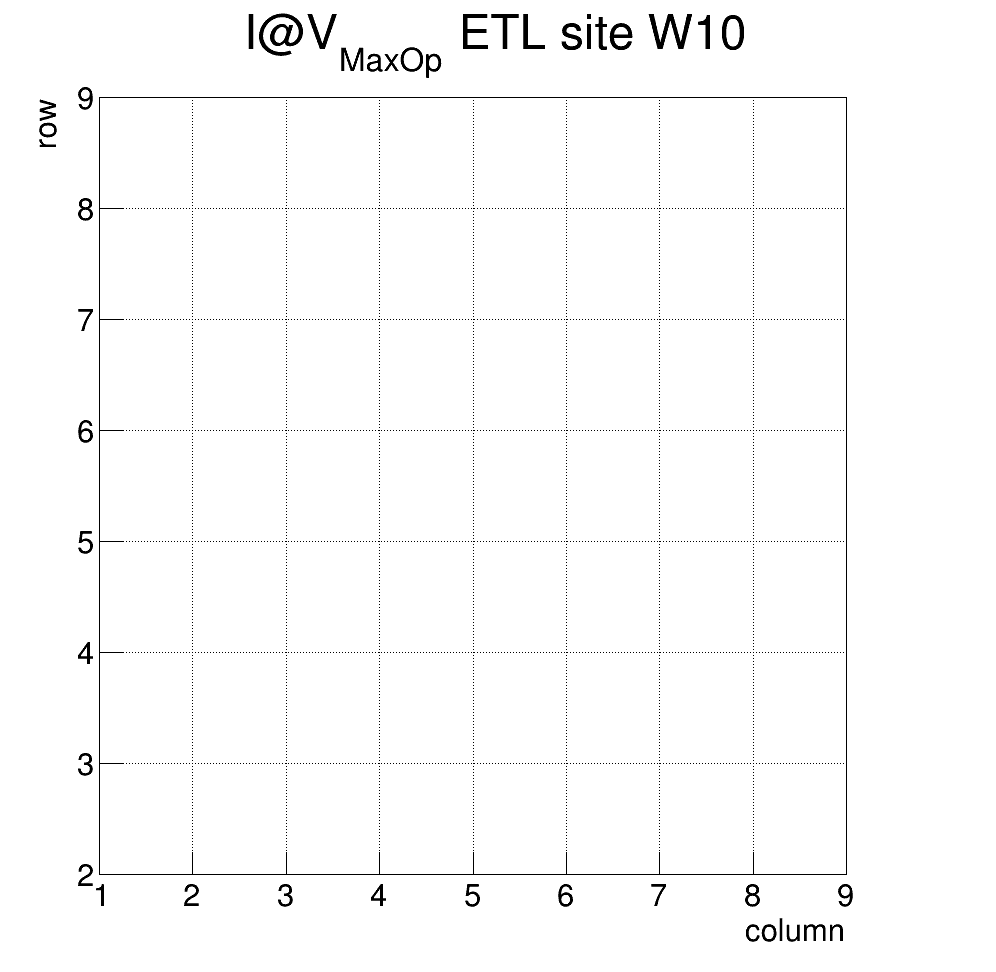

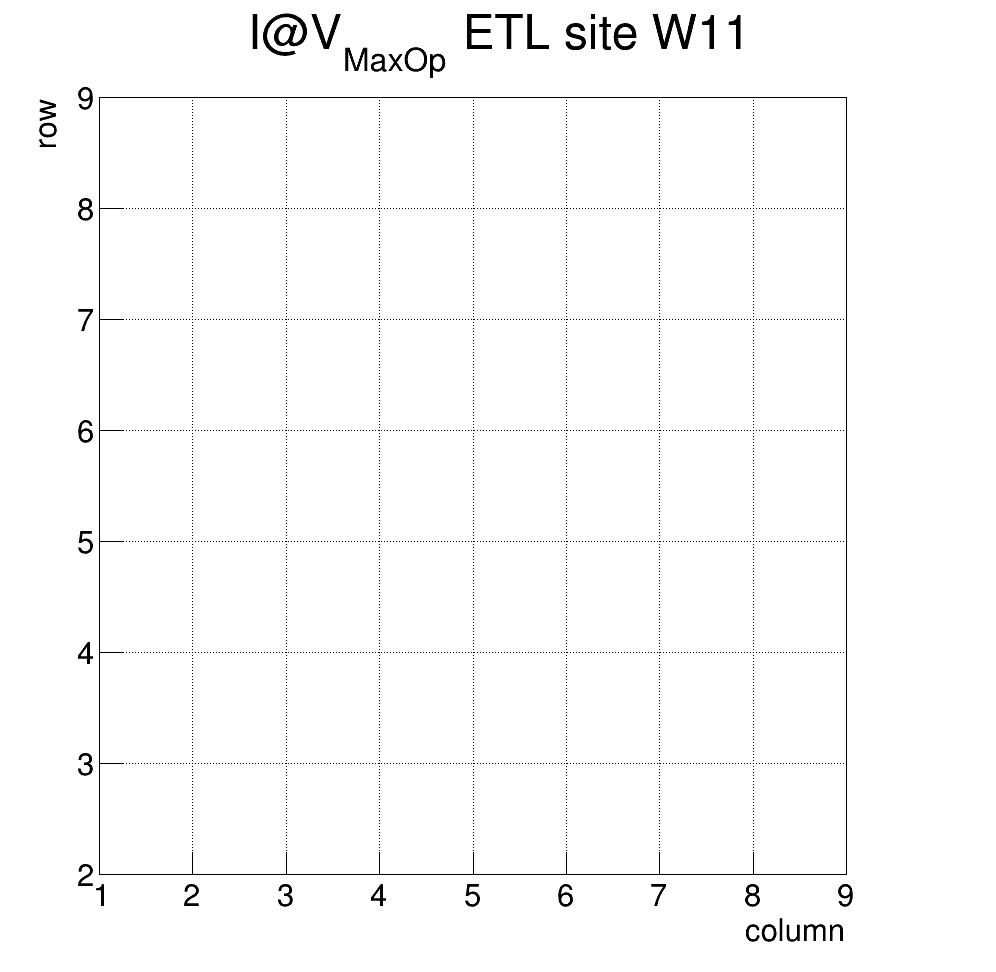

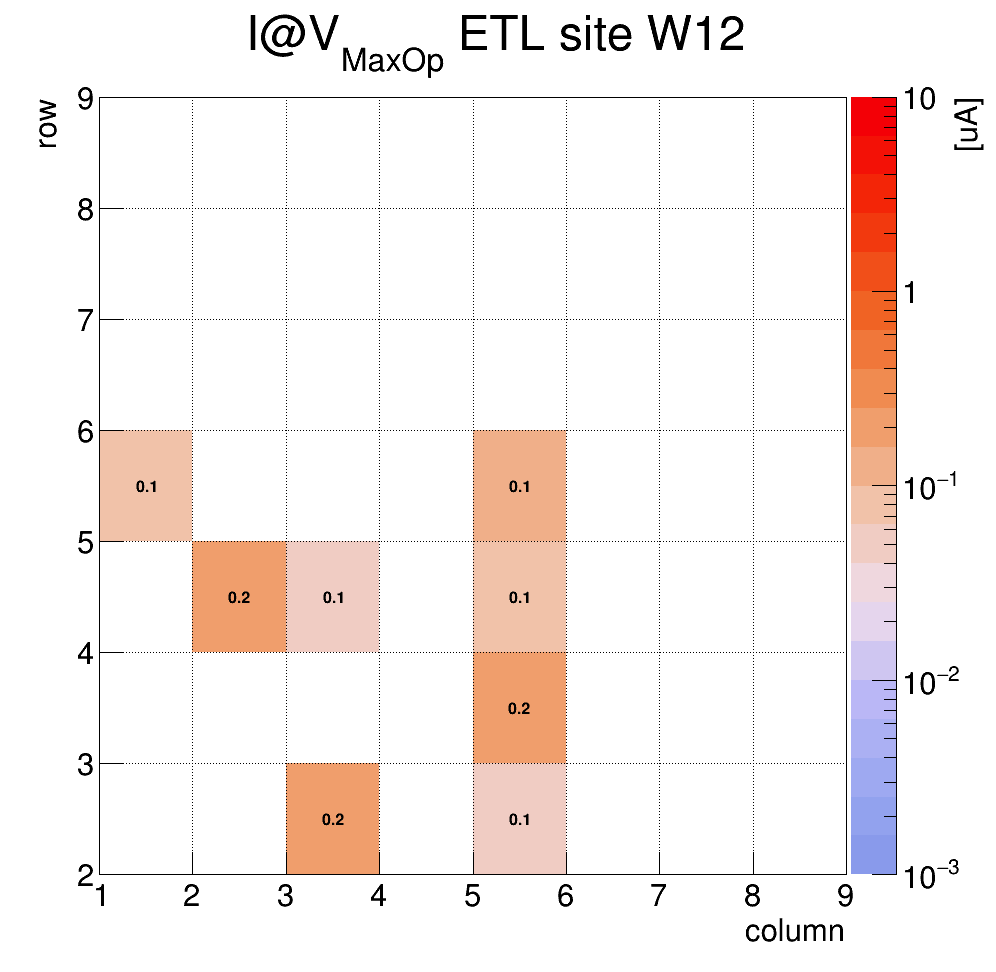

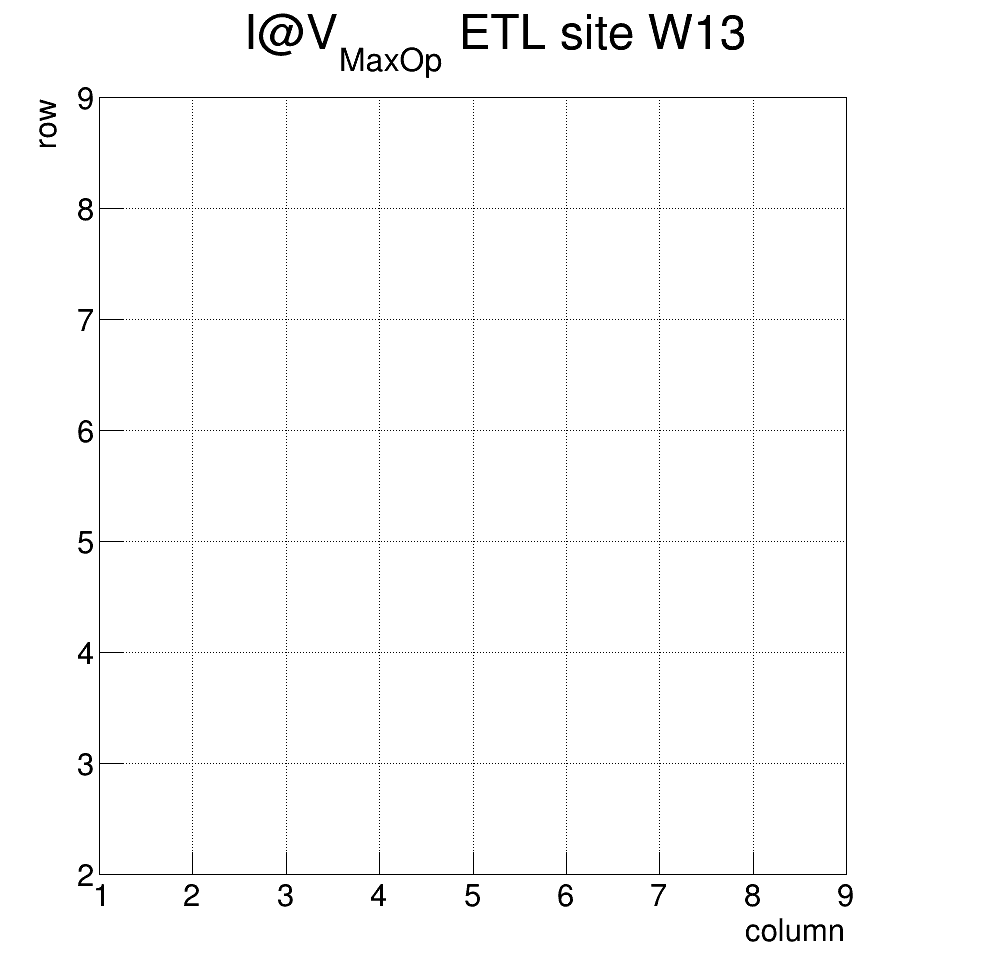

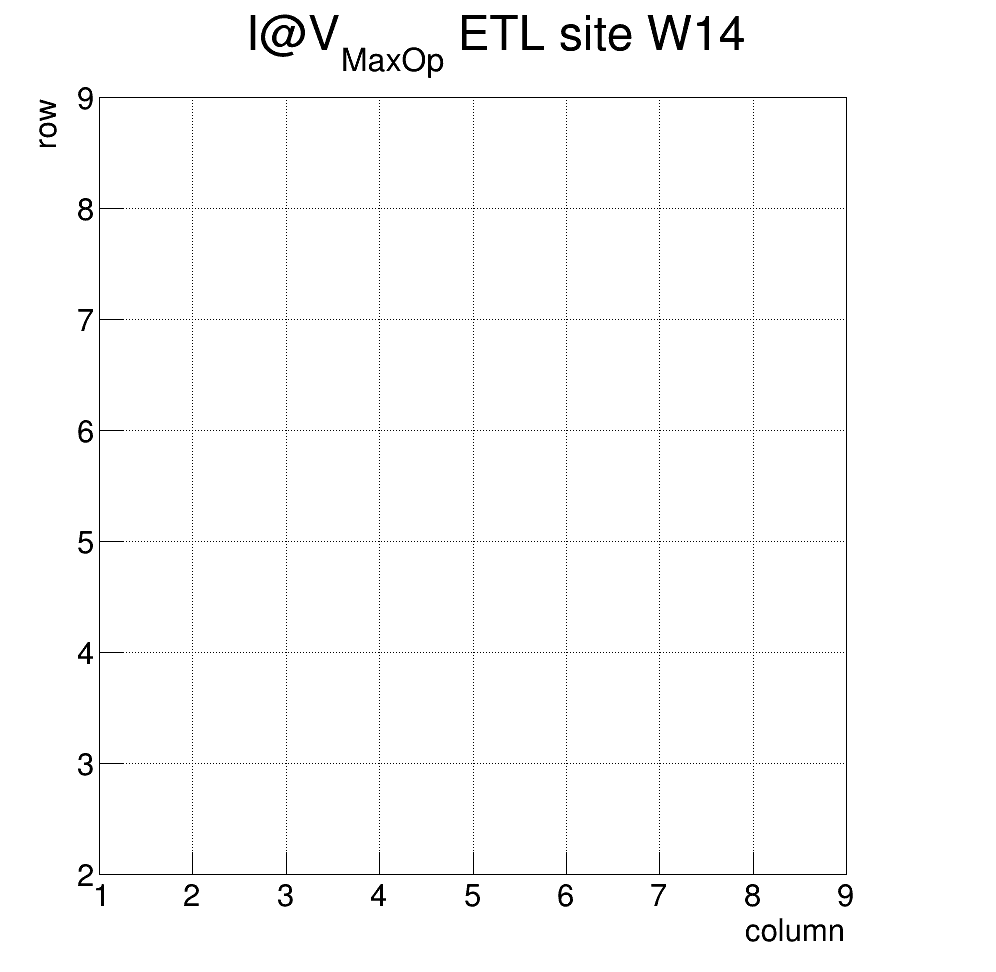

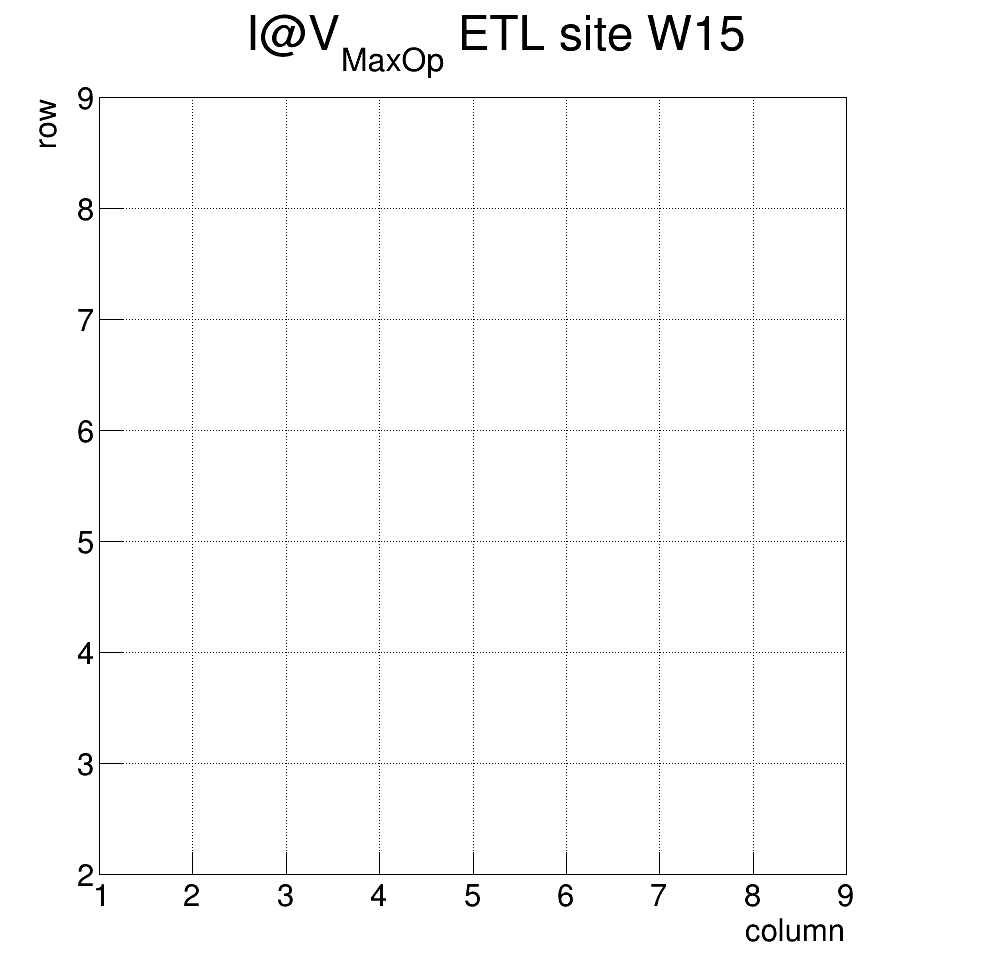

In [5]:
cI_100V = []
cV = []
cbump = []
cnoisy = []

for i in range(n_wafer):
  if(bcurrent):
    cI_100V.append(root.TCanvas("c_I_"+str(V_current_level[i])+"V_W"+str(i+1), "c I@"+str(V_current_level[i])+"V_W"+str(i+1), 1000,1000))
  if(bvoltage):
    cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
  if(bcategory):
    cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
  if(bnoisy):
    cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))


for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

  
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")

    hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
    hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
    hnoisy_qa[i].GetXaxis().SetTitle("column")
    hnoisy_qa[i].GetYaxis().SetTitle("row")


    if(bcurrent):
      #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
      cI_100V[i].SetRightMargin(0.15)
      cI_100V[i].cd()
      hI_qa_100V[i].SetMarkerSize(0.9)
      hI_qa_100V[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.SetLogz(1)
      root.gPad.Update()
      cI_100V[i].Update()
      hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
      hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
  
      if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level[i])+"V_W"+str(i+1)+".png")


    if(bvoltage):
      root.gStyle.SetPaintTextFormat("1.1f")
      #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
      cV[i].SetRightMargin(0.15)
      cV[i].cd()
      hV_qa[i].SetMarkerSize(0.9)
      hV_qa[i].Draw("textcolz")
      #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cV[i].Update()
      hV_qa[i].GetXaxis().SetNdivisions(n_col)
      hV_qa[i].GetYaxis().SetNdivisions(n_row)
  
      if(save): 
        #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
        cV[i].SaveAs(save_path+"VBD_W"+str(i+1)+".png")


    if(bcategory):
      #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
      cbump[i].SetRightMargin(0.15)
      cbump[i].cd()
      hbump_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cbump[i].Update()
      hbump_qa[i].GetXaxis().SetNdivisions(n_col)
      hbump_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
        cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+".png" )   


    if(bnoisy):
      #cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))
      cnoisy[i].SetRightMargin(0.15)
      cnoisy[i].cd()
      hnoisy_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cnoisy[i].Update()
      hnoisy_qa[i].GetXaxis().SetNdivisions(n_col)
      hnoisy_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        cnoisy[i].SaveAs("pics/noisy_W"+str(i+1)+".png")

In [ ]:
#Script to get the Wafer, row, col given the Serial Number as input

from openpyxl import load_workbook

#sserial = 'FBK_LF1_ROL_030'
#pippo_coord = str( wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Wafer'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Column'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Row'].iloc[0] )
# print(pippo_coord)
#str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Row'] == k+start_row) & (wb['Column'] == j+start_col)]['SerialNumber'].iloc[0])

workbook = load_workbook('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')
worksheet = workbook.active  # Assuming you want to search the active sheet

for row in worksheet.iter_rows():
    for cell in row:
      if cell.value == 'FBK_LF1_ROL_030':
        for idd, cell in enumerate(row):
          if idd==4 or idd==6 or idd==7 :
           print(cell.value, end=" ")
        print()

In [ ]:
#Script to produce a xlsx file with a subset of sensors, based on conditions that can be specified

import pandas as pd

# Read the original Excel file
wb = pd.read_excel('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')

# Filter the DataFrame based on your condition
# For example, to filter rows where the value in column 'A' is greater than 10:
filtered_df = wb[wb['Wafer'] == 8]

# Write the filtered DataFrame to a new Excel file
filtered_df.to_excel("/Users/icosivi/Desktop/UFSDLF_16x16_W8.xlsx", index=False)
